In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

In [2]:
import sys
sys.path.append('..')

from micrograd.engine import Value
from micrograd.neuralnet import MLP

In [3]:
random.seed(42)

In [4]:
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
y = 2*(y-0.5)

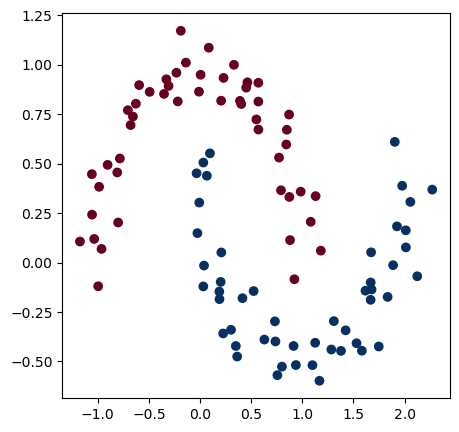

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu')

In [6]:
bin_class = MLP(2, [8, 8, 1])

In [7]:
y_pred = [bin_class(x) for x in X]
y_pred[:10]

[Value(data=0.9465412931266375),
 Value(data=0.2863480630498956),
 Value(data=0.6781745448170433),
 Value(data=-0.9744053444084136),
 Value(data=-0.9476005975233632),
 Value(data=-0.8692122238577313),
 Value(data=0.3346315900943558),
 Value(data=0.9292685691529879),
 Value(data=0.7880494805052146),
 Value(data=0.8912076673368848)]

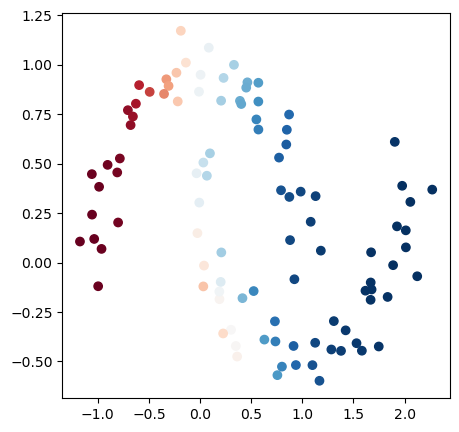

In [8]:
y_prediction = [y.data for y in y_pred]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:,0], X[:,1], c=y_prediction, cmap='RdBu')

In [9]:
def MSE_loss(y_pred, y_target):
    n = len(y_target)
    return sum((target - pred)**2 for target, pred in zip(y_target, y_pred))/n
    

In [10]:
#Training Loop

EPOCHS = 200
for epoch in range(EPOCHS):
    y_pred = [bin_class(x) for x in X]
    loss = MSE_loss(y_pred, y)

    bin_class.zero_grad()
    loss.backward()

    bin_class.SGDoptimize()

    print(f'EPOCH: {epoch}  |  Loss: {loss.data:.4f}')

EPOCH: 0  |  Loss: 0.8946
EPOCH: 1  |  Loss: 0.7384
EPOCH: 2  |  Loss: 0.6280
EPOCH: 3  |  Loss: 0.5498
EPOCH: 4  |  Loss: 0.4918
EPOCH: 5  |  Loss: 0.4464
EPOCH: 6  |  Loss: 0.4099
EPOCH: 7  |  Loss: 0.3803
EPOCH: 8  |  Loss: 0.3566
EPOCH: 9  |  Loss: 0.3378
EPOCH: 10  |  Loss: 0.3232
EPOCH: 11  |  Loss: 0.3119
EPOCH: 12  |  Loss: 0.3033
EPOCH: 13  |  Loss: 0.2965
EPOCH: 14  |  Loss: 0.2911
EPOCH: 15  |  Loss: 0.2867
EPOCH: 16  |  Loss: 0.2828
EPOCH: 17  |  Loss: 0.2794
EPOCH: 18  |  Loss: 0.2762
EPOCH: 19  |  Loss: 0.2732
EPOCH: 20  |  Loss: 0.2704
EPOCH: 21  |  Loss: 0.2677
EPOCH: 22  |  Loss: 0.2651
EPOCH: 23  |  Loss: 0.2625
EPOCH: 24  |  Loss: 0.2600
EPOCH: 25  |  Loss: 0.2575
EPOCH: 26  |  Loss: 0.2551
EPOCH: 27  |  Loss: 0.2526
EPOCH: 28  |  Loss: 0.2502
EPOCH: 29  |  Loss: 0.2478
EPOCH: 30  |  Loss: 0.2454
EPOCH: 31  |  Loss: 0.2430
EPOCH: 32  |  Loss: 0.2407
EPOCH: 33  |  Loss: 0.2383
EPOCH: 34  |  Loss: 0.2359
EPOCH: 35  |  Loss: 0.2336
EPOCH: 36  |  Loss: 0.2312
EPOCH: 37  

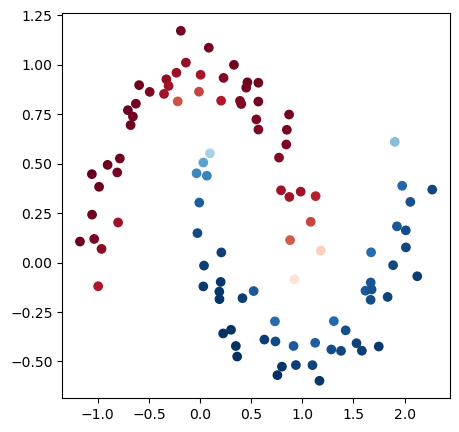

In [17]:
y_pred = [bin_class(x).data for x in X]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:,0], X[:,1], c=y_pred, cmap='RdBu')

In [18]:
def accuracy(preds, target):
    return sum(pred == target for pred, target in zip(preds, target))/len(target)

In [22]:
preds = [1 if pred >= 0 else -1 for pred in y_pred]
print(f'Accuracy: {accuracy(preds, y)*100:.2f}%')

Accuracy: 100.00%


In [ ]:
def plot_decision_boundary(model, X, y):
    # create a grid of points
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # run every grid point through the model
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = [model([x1, x2]).data for x1, x2 in grid_points]
    Z = np.array(Z).reshape(xx.shape)
    
    # plot
    plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)
    plt.colorbar()
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
    plt.title("MLP Decision Boundary")
    plt.show()

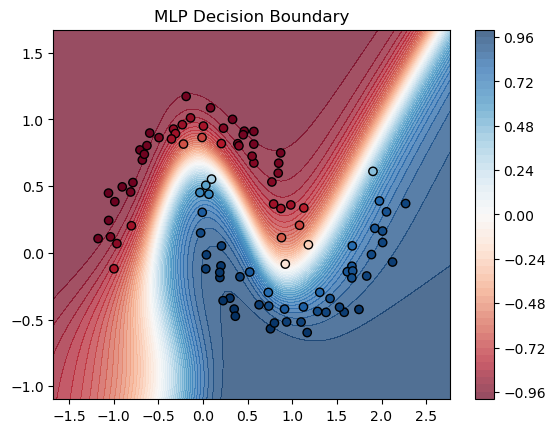

In [21]:
plot_decision_boundary(bin_class, X, y_pred)